In [2]:
import pandas as pd
from scipy.stats import ttest_ind
import matplotlib.pyplot as plt
import statsmodels.api as sm
import plotly.express as px
import numpy as np
import seaborn as sns

In [5]:
print('============= ZADANIE 1 =============')
data = pd.read_csv('data/08/wyniki.csv')

print("Podgląd danych:")
print(data.head())

female_scores = data[data['plec'] == 'F']['ocena_koncowa']
male_scores = data[data['plec'] == 'M']['ocena_koncowa']

t_stat, p_value = ttest_ind(female_scores, male_scores)

# Ustalenie poziomu istotności
alpha = 0.05

# Wyniki
print("\nWyniki testu t-Studenta:")
print(f"Statystyka t: {t_stat}")
print(f"P-wartość: {p_value}")

if p_value < alpha:
    print("Odrzucamy hipotezę zerową: istnieje istotna różnica w ocenach końcowych pomiędzy uczniami i uczennicami.")
else:
    print("Nie ma podstaw do odrzucenia hipotezy zerowej: brak istotnej różnicy w ocenach końcowych pomiędzy uczniami i uczennicami.")


============= ZADANIE 1 =============
Podgląd danych:
  plec  ocena_koncowa
0    F              6
1    F              6
2    F             10
3    F             15
4    F             10

Wyniki testu t-Studenta:
Statystyka t: -1.9404771273257526
P-wartość: 0.053113174845791505
Nie ma podstaw do odrzucenia hipotezy zerowej: brak istotnej różnicy w ocenach końcowych pomiędzy uczniami i uczennicami.



============= ZADANIE 2 =============
Podgląd danych:
    Rok  Zysk
0  1821  1645
1  1822   658
2  1823  1926
3  1824   865
4  1825   764


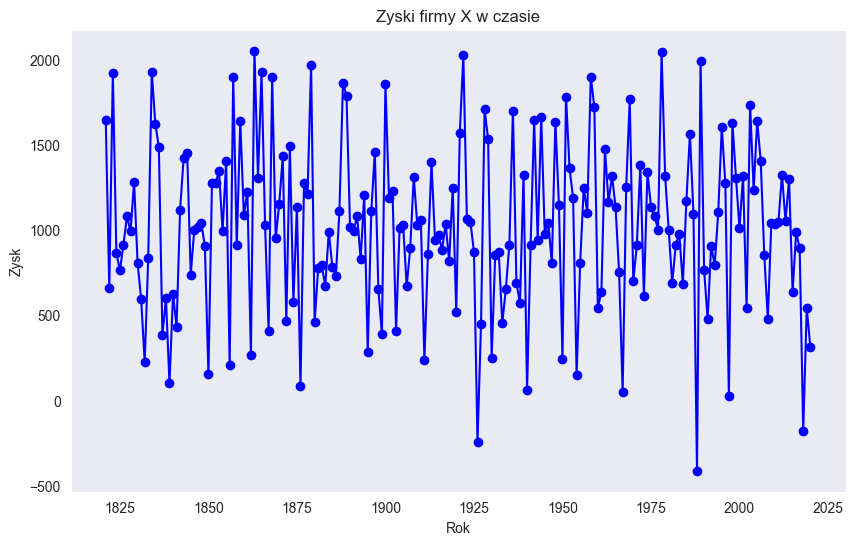


Podsumowanie modelu regresji liniowej:
                            OLS Regression Results                            
Dep. Variable:                   Zysk   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.005
Method:                 Least Squares   F-statistic:                   0.09357
Date:                Sat, 07 Dec 2024   Prob (F-statistic):              0.760
Time:                        19:33:50   Log-Likelihood:                -1521.3
No. Observations:                 200   AIC:                             3047.
Df Residuals:                     198   BIC:                             3053.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       

In [7]:
print('\n============= ZADANIE 2 =============')
data = pd.read_csv('data/08/ZyskiFirmyX.csv')

print("Podgląd danych:")
print(data.head())

plt.figure(figsize=(10, 6))
plt.plot(data['Rok'], data['Zysk'], marker='o', linestyle='-', color='b')
plt.title('Zyski firmy X w czasie')
plt.xlabel('Rok')
plt.ylabel('Zysk')
plt.grid()
plt.show()

X = data['Rok']
Y = data['Zysk']
X = sm.add_constant(X)

model = sm.OLS(Y, X).fit()

# Podsumowanie modelu
print("\nPodsumowanie modelu regresji liniowej:")
print(model.summary())


============= ZADANIE 3 =============

1. - model regresji liniowej


Podgląd danych:
   Gender  Age  AnnualIncome  SpendingScore
0    Male   19            15             39
1    Male   21            15             81
2  Female   20            16              6
3  Female   23            16             77
4  Female   31            17             40
                            OLS Regression Results                            
Dep. Variable:          SpendingScore   R-squared:                       0.109
Model:                            OLS   Adj. R-squared:                  0.095
Method:                 Least Squares   F-statistic:                     7.960
Date:                Sun, 08 Dec 2024   Prob (F-statistic):           4.91e-05
Time:                        12:52:37   Log-Likelihood:                -922.05
No. Observations:                 200   AIC:                             1852.
Df Residuals:                     196   BIC:                             1865.
Df Model:         

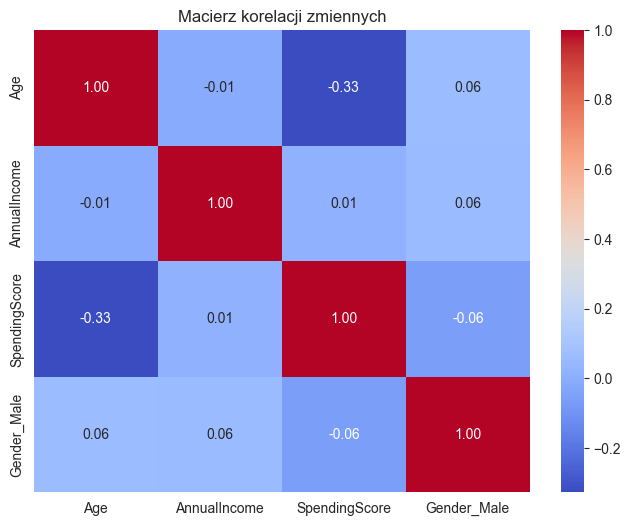


4 - usunięcie najmniej istotnej zmiennej (JEDNEJ ZMIENNEJ - zgodnie z treścią zadania)


Wszystkie wartości p-wartości:
Wszystkie wartości p-wartości w zapisie dziesiętnym:
const           0.00000000
Age             0.00000306
AnnualIncome    0.90509393
Gender_Male     0.56711719
dtype: object

Usuwam zmienną AnnualIncome z modelu o wartości: 0.9051.

Nowe podsumowanie modelu regresji liniowej:
                            OLS Regression Results                            
Dep. Variable:          SpendingScore   R-squared:                       0.109
Model:                            OLS   Adj. R-squared:                  0.099
Method:                 Least Squares   F-statistic:                     11.99
Date:                Sun, 08 Dec 2024   Prob (F-statistic):           1.22e-05
Time:                        12:52:37   Log-Likelihood:                -922.05
No. Observations:                 200   AIC:                             1850.
Df Residuals:                     197   BIC:    

In [19]:
print('============= ZADANIE 3 =============\n')
print('1. - model regresji liniowej\n\n')
data = pd.read_csv('data/08/spendingscores.csv')

print("Podgląd danych:")
print(data.head())

X = data.drop(columns=['SpendingScore'])
# Konwersja zmiennej kategorycznej Gender na kody numeryczne
X = pd.get_dummies(X, drop_first=True)
# Upewnienie się, że wszystkie dane są typu float - bez tego miałem błędy przy tworzeniu modelu regresji
X = X.astype(float)

Y = data['SpendingScore']
X = sm.add_constant(X)
model = sm.OLS(Y, X).fit()

print(model.summary())

print('\n2 - dodatkowe informacje z modelu\n\n')

print('P-values')
print(model.pvalues)
print('Standard dev')
print(model.bse)
print('Coefficients')
print(model.params)

print('\n3 - korelacja pomiędzy zmiennymi\n\n')

data_prepared = data.copy()
# zmiana gender na wartości liczbowe
data_prepared = pd.get_dummies(data_prepared, columns=['Gender'], drop_first=True)
correlation_matrix = data_prepared.corr()

print("Macierz korelacji:")
print(correlation_matrix)

# Wizualizacja - z seaborna jest ładniejsza
# fig = px.imshow(
#     correlation_matrix,
#     text_auto=True,
#     title="Macierz korelacji zmiennych",
#     color_continuous_scale="Viridis"
# )
# 
# fig.show()

plt.figure(figsize=(8,6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Macierz korelacji zmiennych")
plt.show()

print('\n4 - usunięcie najmniej istotnej zmiennej (JEDNEJ ZMIENNEJ - zgodnie z treścią zadania)\n\n')

p_values = model.pvalues
excluded_variable = p_values.idxmax()

print("Wszystkie wartości p-wartości:")
p_values_decimal = p_values.map(lambda x: f"{x:.8f}")
print("Wszystkie wartości p-wartości w zapisie dziesiętnym:")
print(p_values_decimal)

print(f"\nUsuwam zmienną {excluded_variable} z modelu o wartości: {p_values[excluded_variable]:.4f}.")

X_reduced = X.drop(columns=[excluded_variable])
model_reduced = sm.OLS(Y, X_reduced).fit()

print("\nNowe podsumowanie modelu regresji liniowej:")
print(model_reduced.summary())